# Weak Signal Diagnostic Report

4D skeleton → graph → morphometry pipeline diagnostic. Loads outputs from Phases 2–5 and summarizes findings.


## 1. Setup

Notebook lives in `analysis/`; paths are relative to this directory.

In [1]:
from pathlib import Path

import pandas as pd

REPORT_DIR = Path()
assert REPORT_DIR.exists(), "Run from analysis/ directory or set REPORT_DIR"

## 2. Phase 2 – Per-feature QC and Sanity Checks

In [2]:
# QC per feature
MAX_MISSING_PCT = 30
qc = pd.read_csv(REPORT_DIR / "qc_per_feature.csv")
print(f"Features: {len(qc)}")
print(
    f"Constant: {qc['is_constant'].sum()}, High missing (>{MAX_MISSING_PCT}%): {(qc['missing_pct'] > MAX_MISSING_PCT).sum()}"
)
qc.head(10)

Features: 117
Constant: 1, High missing (>30%): 0


,feature,missing_pct,is_constant,nan_count,inf_count,outlier_pct,n_valid
0,component_1__segment__start__mean,0.069348,False,1,0,0.000000,1441
1,component_1__segment__start__std,0.069348,False,1,0,0.000000,1441
2,component_1__segment__start__min,0.069348,False,1,0,0.000000,1441
3,component_1__segment__start__max,0.069348,False,1,0,0.000000,1441
4,component_1__segment__start__count,0.069348,False,1,0,1.525659,1441
5,component_1__segment__end__mean,0.069348,False,1,0,0.000000,1441
6,component_1__segment__end__std,0.069348,False,1,0,0.000000,1441
7,component_1__segment__end__min,0.069348,False,1,0,0.000000,1441
8,component_1__segment__end__max,0.069348,False,1,0,0.000000,1441
9,component_1__segment__end__count,0.069348,False,1,0,1.525659,1441


In [3]:
# Sanity violations
vio_path = REPORT_DIR / "sanity_violations.csv"
if vio_path.exists():
    vio = pd.read_csv(vio_path)
    print(f"Sanity violations: {len(vio)}")
    if len(vio) > 0:
        display(vio.head(10))
else:
    print("No sanity_violations.csv")

No sanity_violations.csv


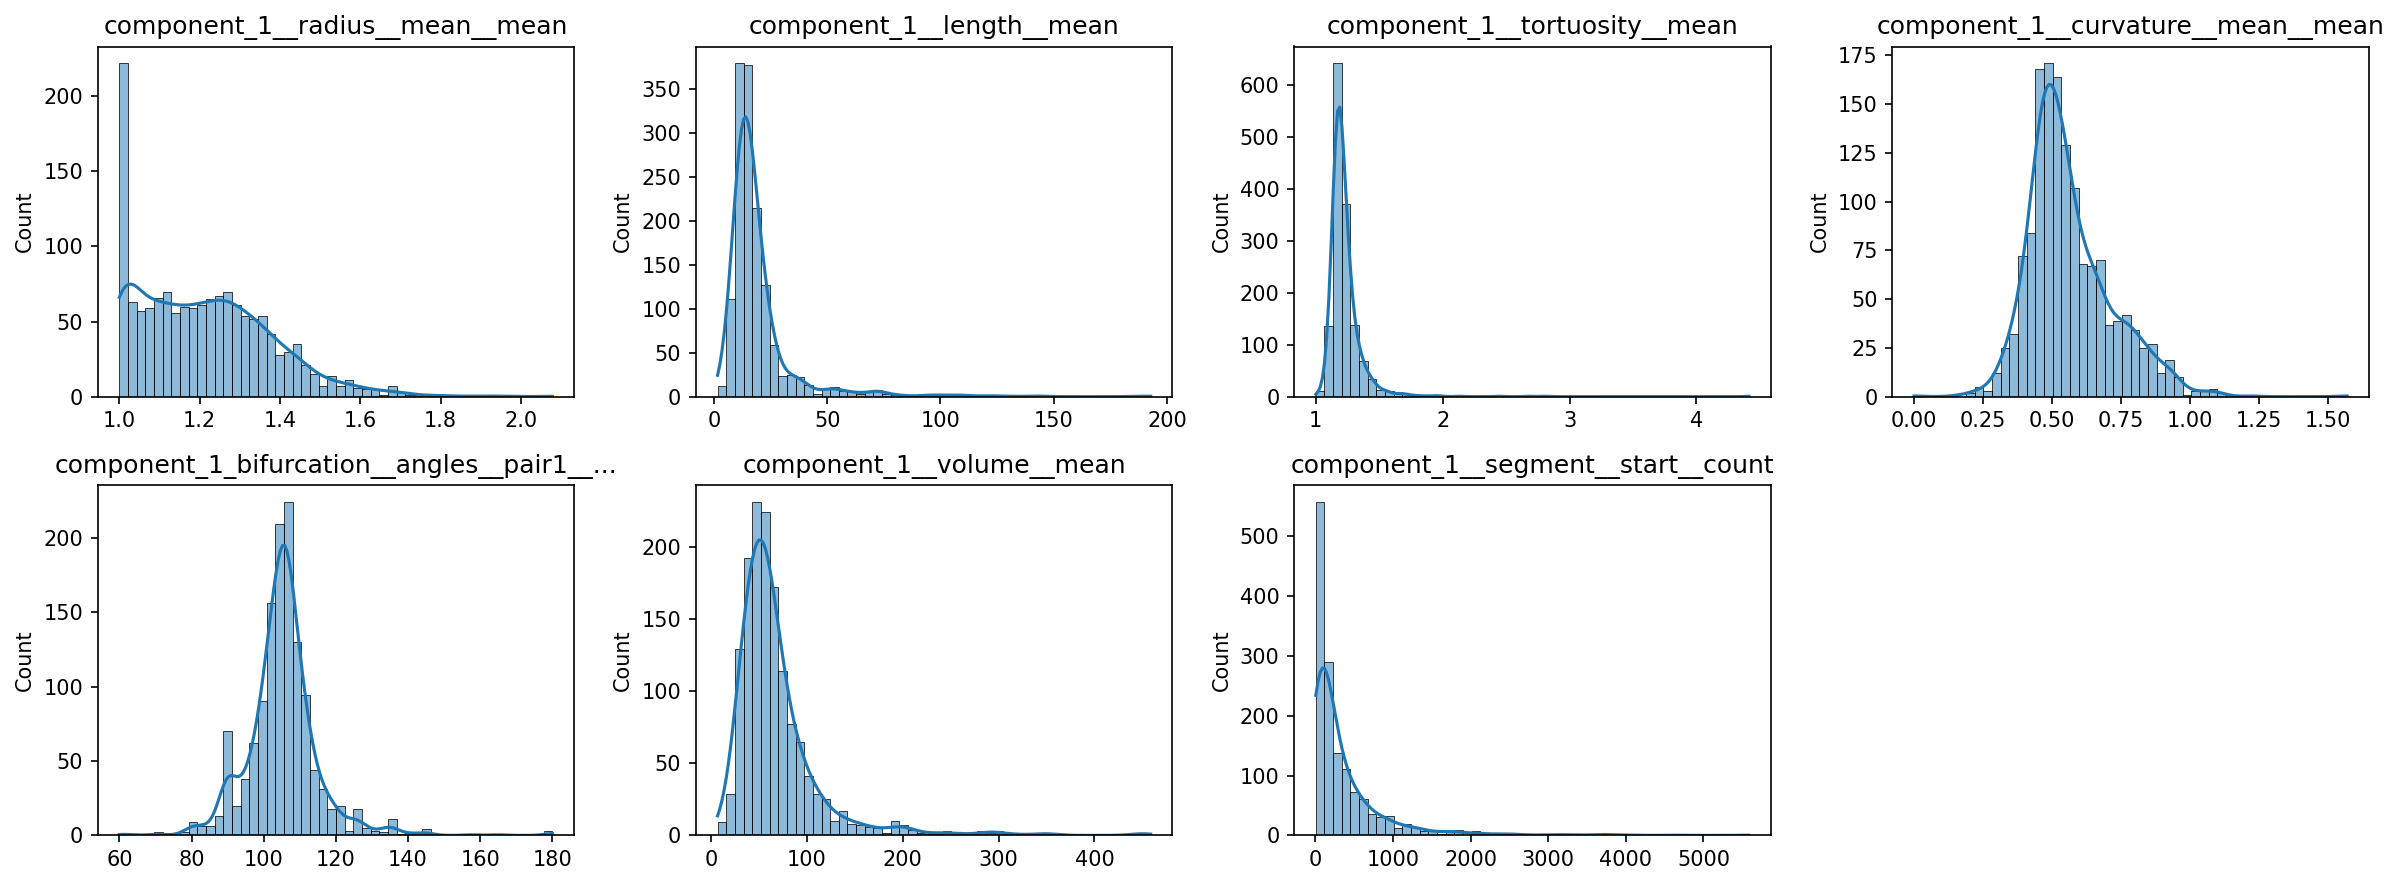

In [4]:
# Distribution plots
from IPython.display import Image, display

dist_path = REPORT_DIR / "plots" / "distributions_core.png"
if dist_path.exists():
    display(Image(filename=str(dist_path), width=800))

## 3. Phase 3 – Batch Effect and Nuisance Analysis

### Colored by pcr


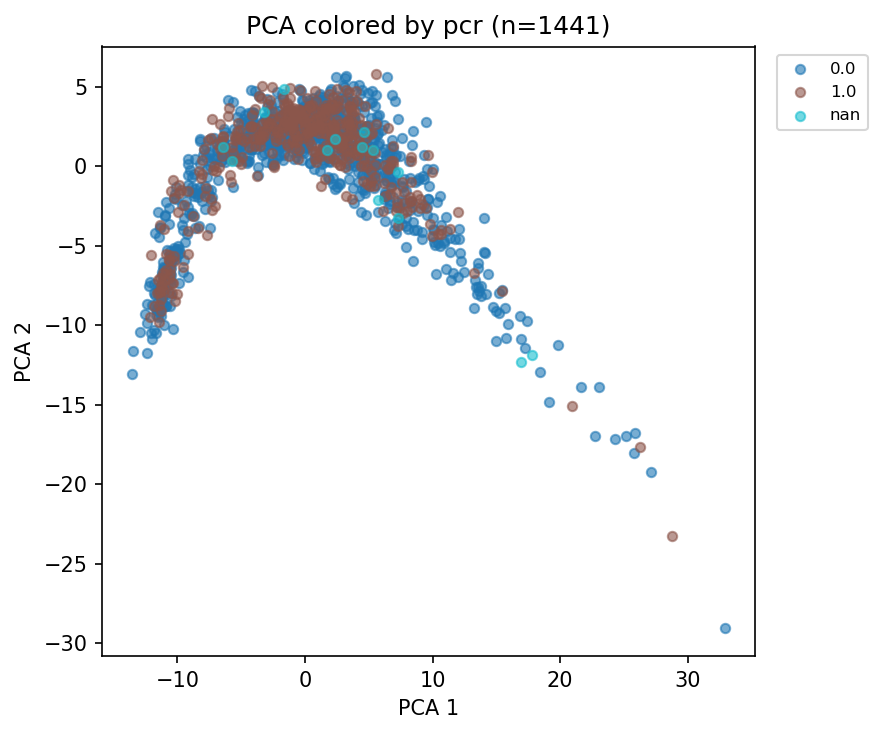

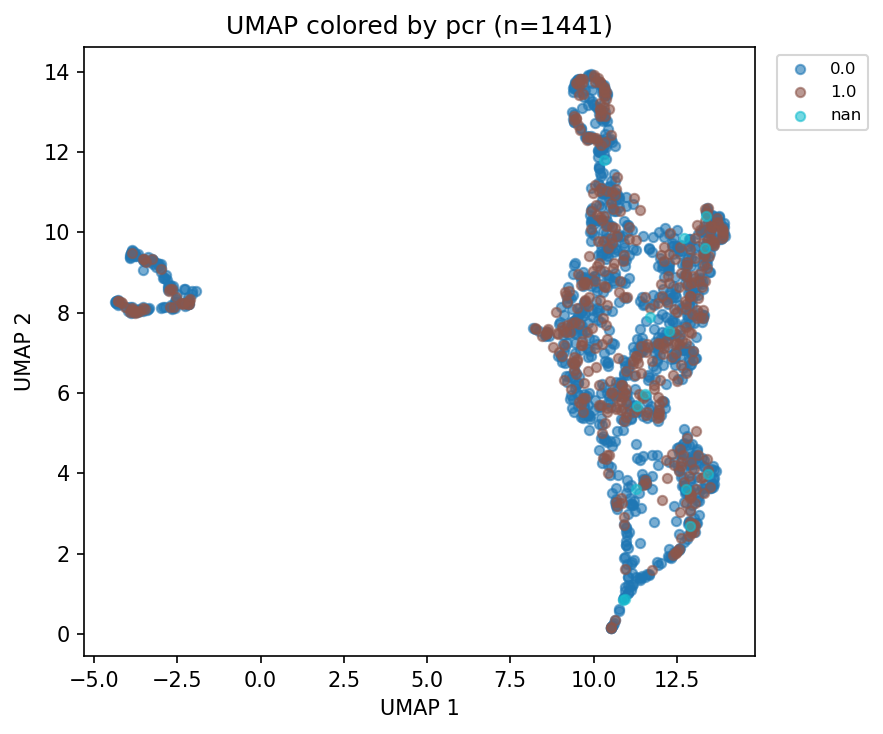

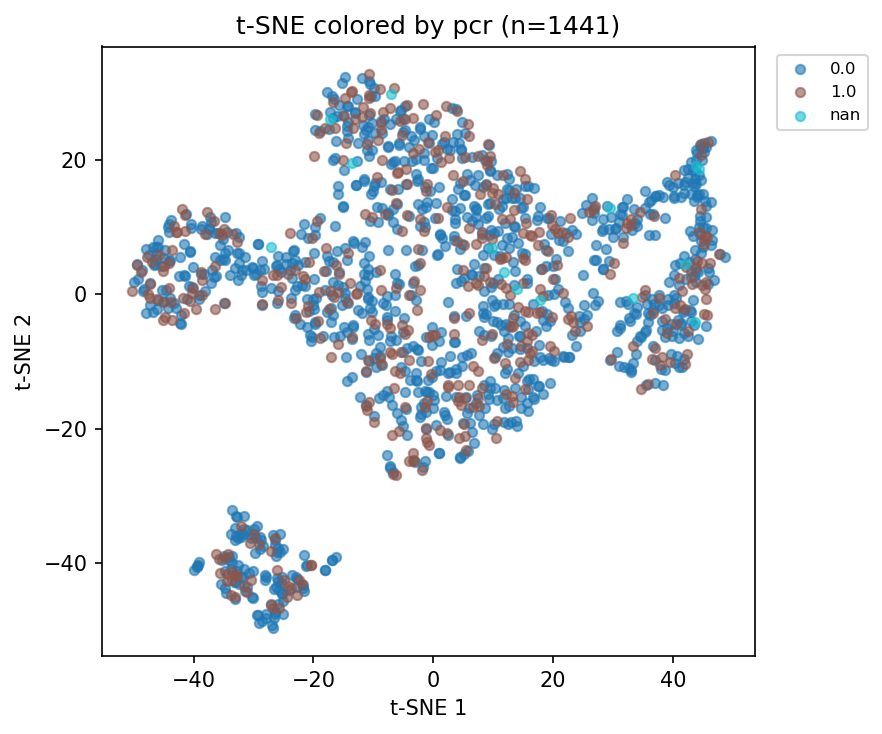

### Colored by site


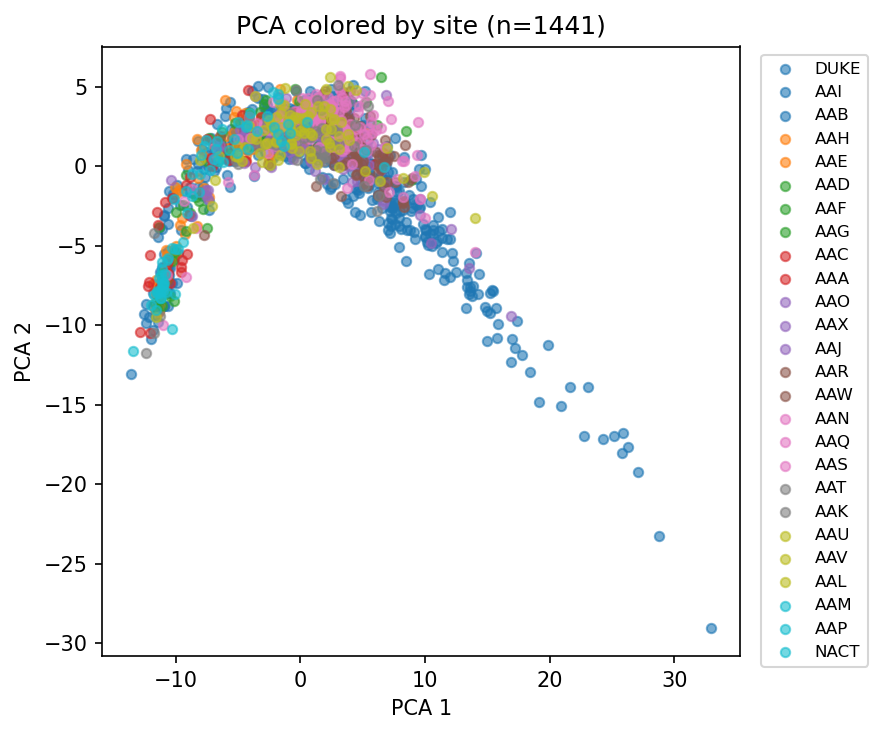

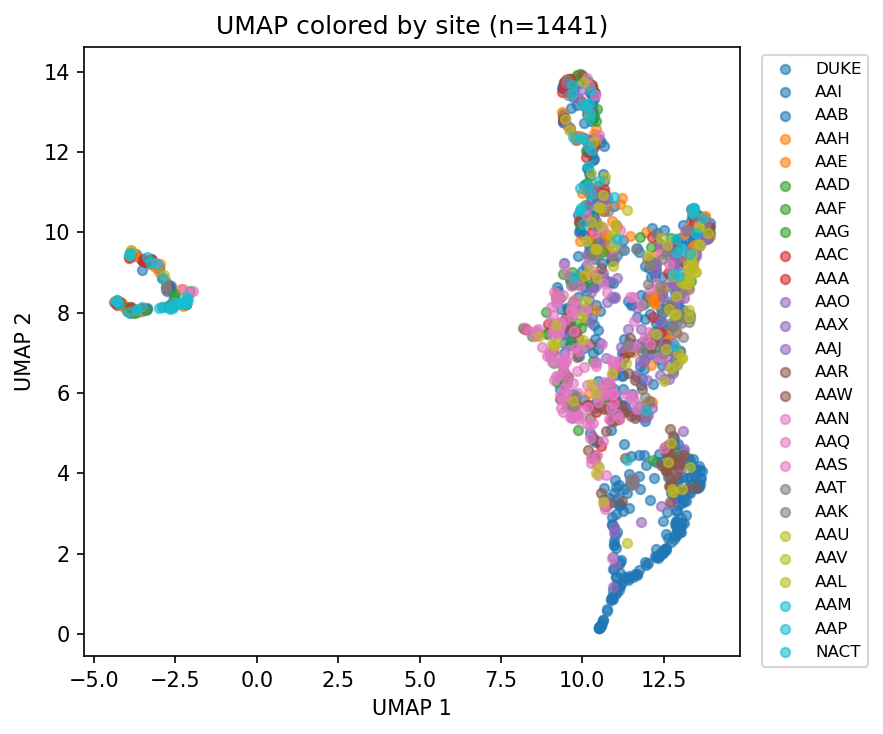

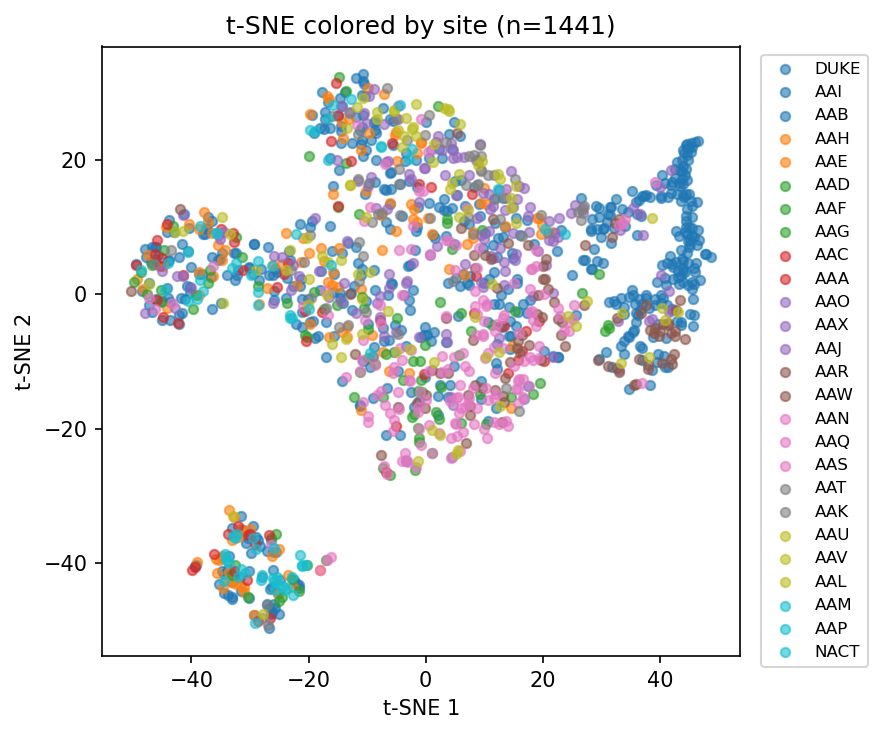

### Colored by dataset


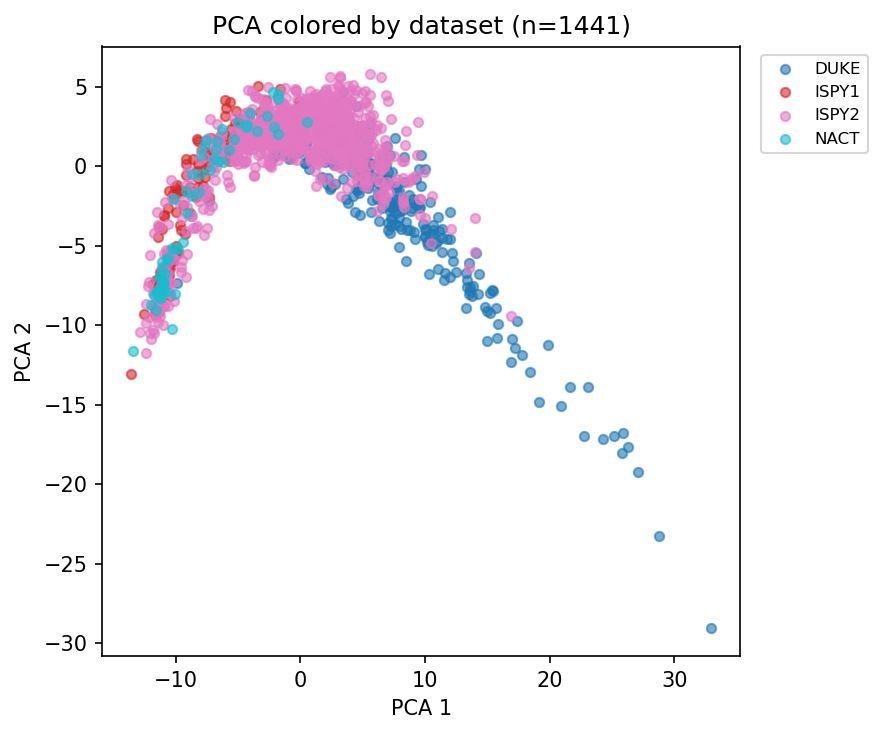

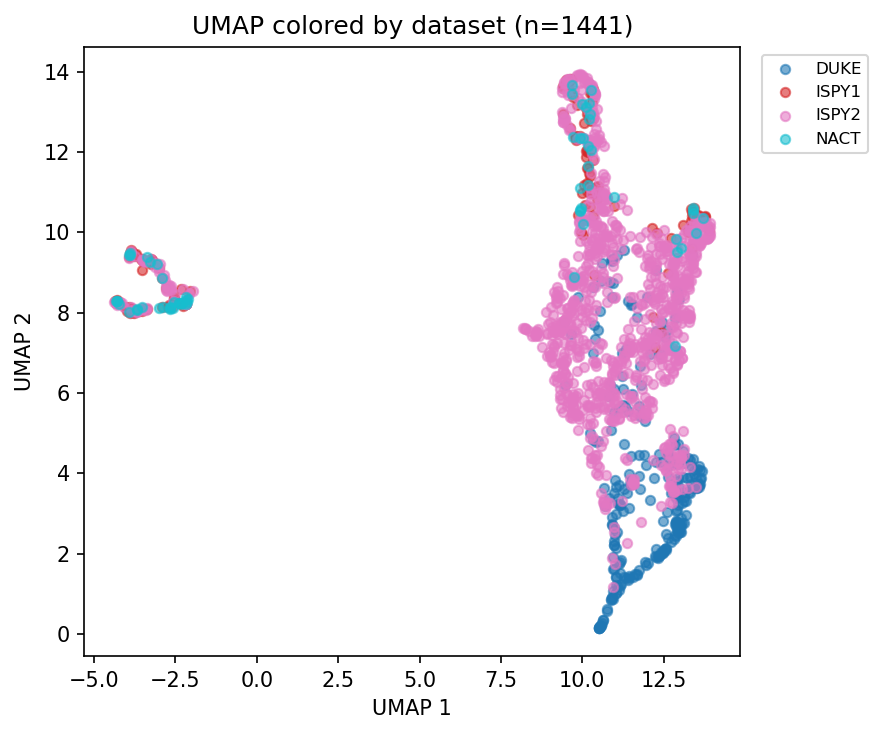

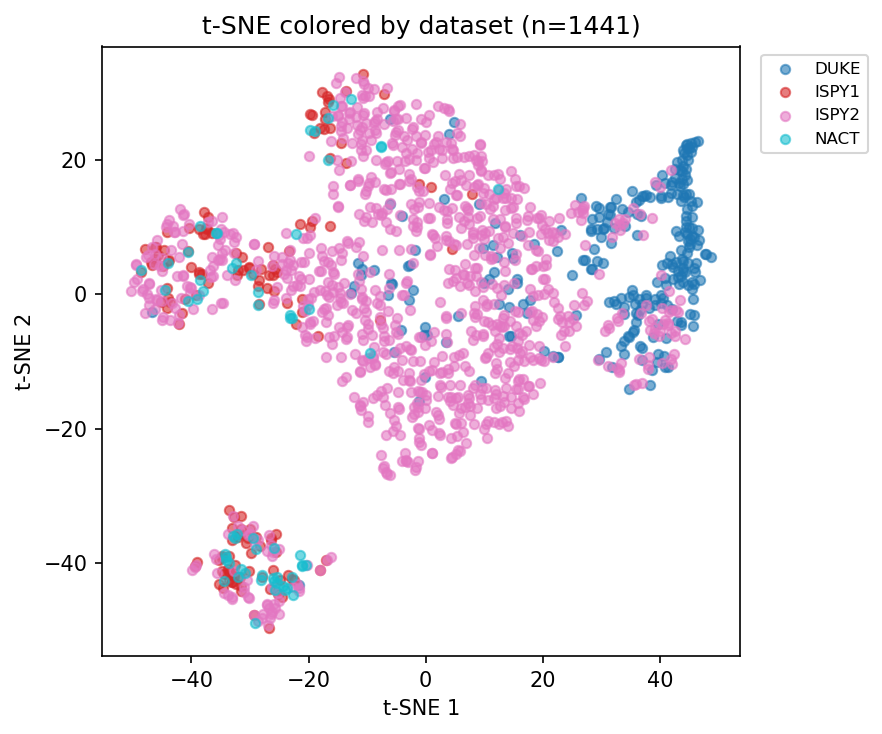

### Colored by manufacturer


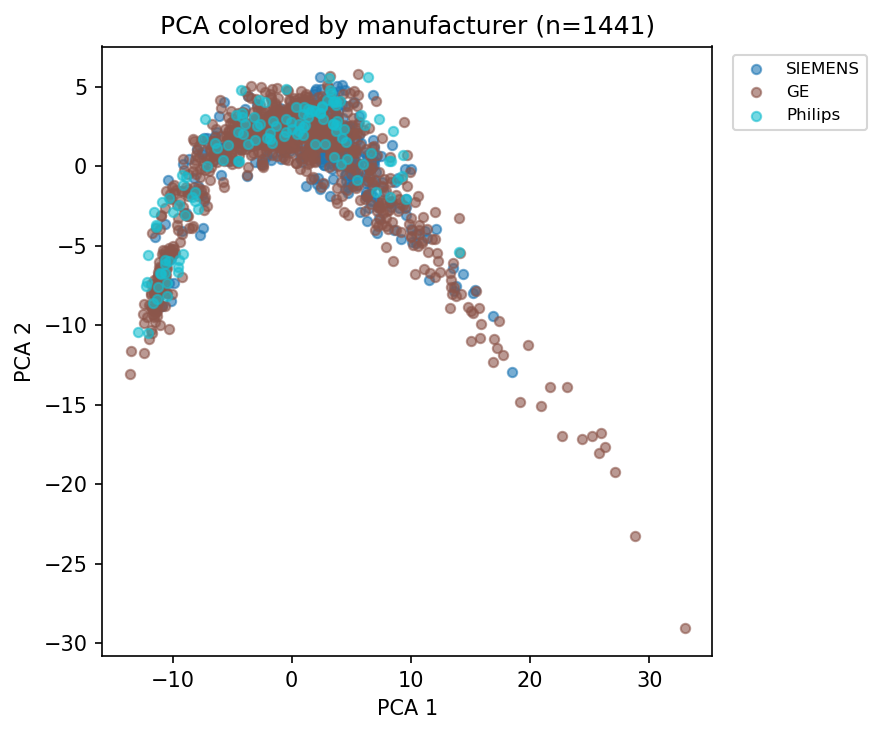

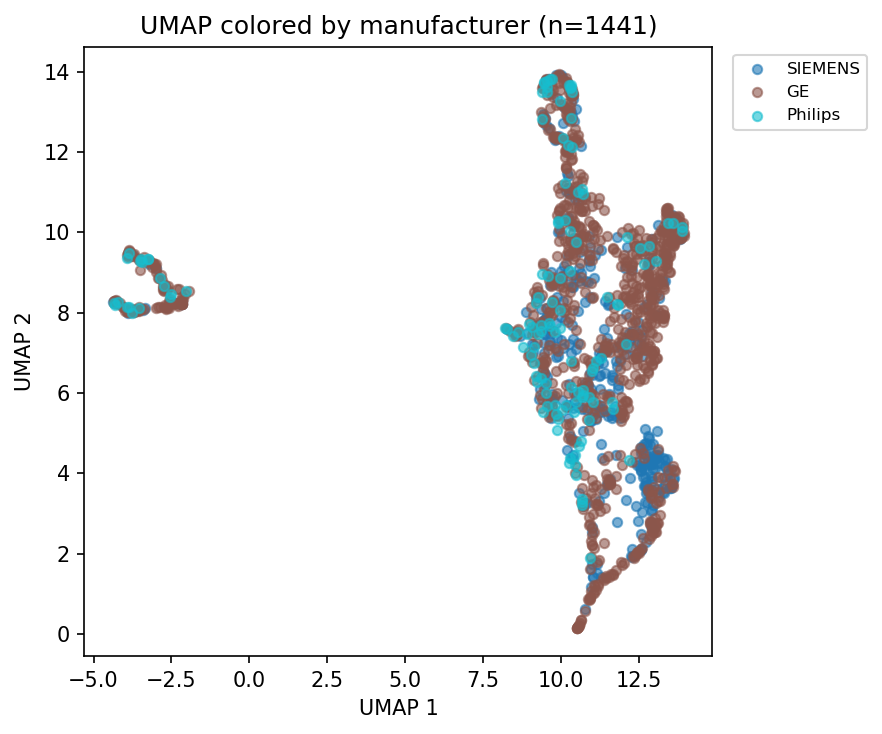

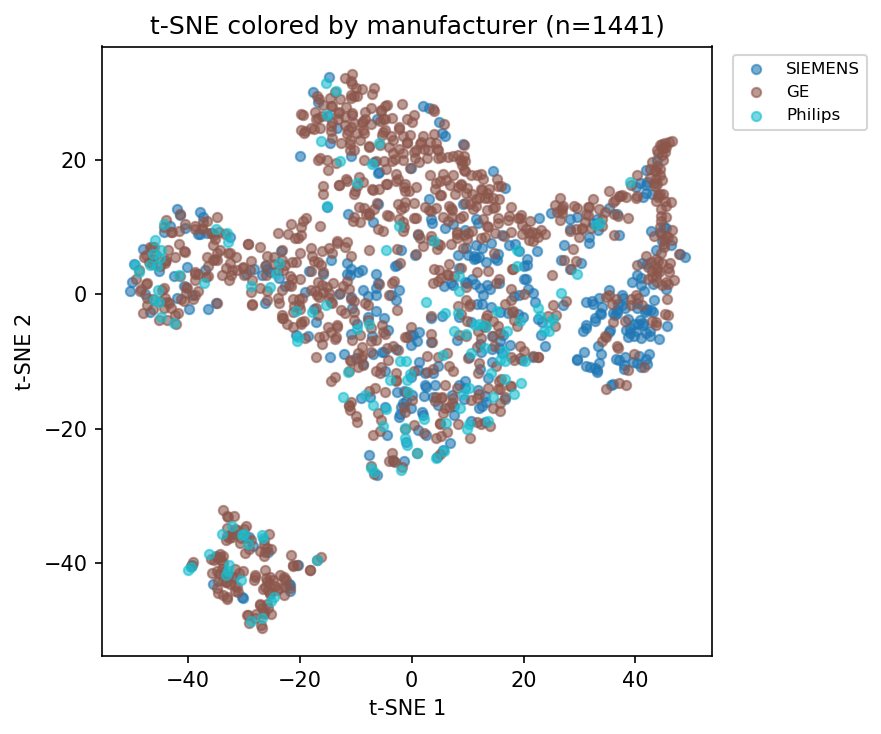

In [5]:
# PCA/UMAP/t-SNE colored by label, site, dataset, manufacturer
import json

for var in ["pcr", "site", "dataset", "manufacturer"]:
    print(f"### Colored by {var}")
    for method in ["pca", "umap", "t-sne"]:
        p = REPORT_DIR / "plots" / f"{method}_colored_by_{var}.png"
        if p.exists():
            display(Image(filename=str(p), width=480))

In [6]:
# Site prediction (batch-effect indicator)
metrics_path = REPORT_DIR / "site_prediction_metrics.json"
if metrics_path.exists():
    with metrics_path.open() as f:
        m = json.load(f)
    print(f"Site prediction AUC macro: {m['auc_macro']:.3f}")
    print(f"Interpretation: {m['interpretation']}")

Site prediction AUC macro: 0.861
Interpretation: strong batch encoding (confounding risk)


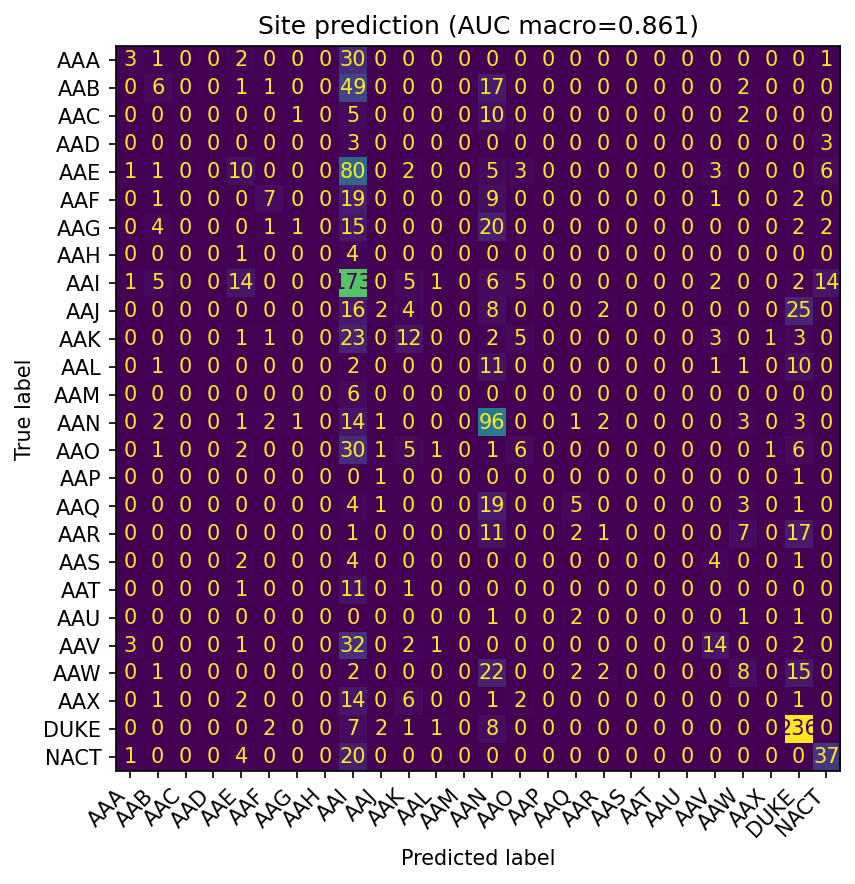

In [7]:
# Confusion matrix
conf_path = REPORT_DIR / "plots" / "site_prediction_confusion.png"
if conf_path.exists():
    display(Image(filename=str(conf_path), width=600))

## 4. Phase 4 – Ablation Study

In [8]:
abl = pd.read_csv(REPORT_DIR / "ablation_results.csv")
display(abl)

,ablation,n_features,auc,ap
0,full,114,0.569882,0.387121
1,no_coordinate_like,99,0.540919,0.345500
2,geometry_only,84,0.542053,0.330331
3,count_only,23,0.475160,0.278006


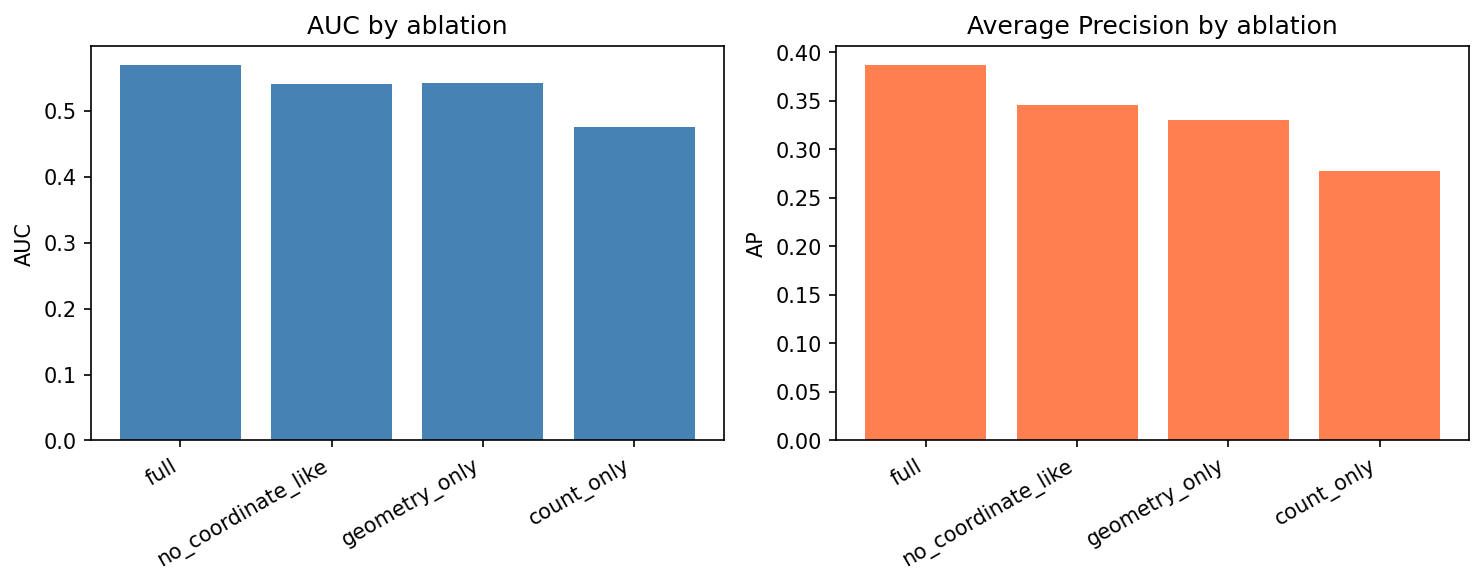

In [9]:
abl_plot = REPORT_DIR / "plots" / "ablation_auc_comparison.png"
if abl_plot.exists():
    display(Image(filename=str(abl_plot), width=700))

## 5. Phase 5 – FP/FN Case Inspection

In [10]:
fp_fn = pd.read_csv(REPORT_DIR / "fp_fn_cases.csv")
print(f"Top FP/FN: {len(fp_fn)} cases")
display(fp_fn)

Top FP/FN: 10 cases


,case_id,y_true,y_pred_proba,fp_or_fn
0,ISPY1_1144,1,0.110356,fn
1,DUKE_652,1,0.176467,fn
2,ISPY1_1073,1,0.185210,fn
3,ISPY2_814299,1,0.193519,fn
4,ISPY2_929980,1,0.196426,fn
5,ISPY1_1088,1,0.202929,fn
6,ISPY2_892390,1,0.206624,fn
7,ISPY1_1051,1,0.216106,fn
8,ISPY2_835658,1,0.216861,fn
9,ISPY2_188091,1,0.230049,fn


In [11]:
# Outlier summary
out_path = REPORT_DIR / "fp_fn_outliers.csv"
if out_path.exists():
    out = pd.read_csv(out_path)
    n_out = out[out["feature"] == "_n_outliers"]
    if len(n_out) > 0:
        print("Cases with extreme feature outliers (|z|>3):")
        display(n_out)
    else:
        print("Outlier rows:")
        display(out.head(15))
else:
    print("No fp_fn_outliers.csv")

Cases with extreme feature outliers (|z|>3):


,case_id,feature,value,z_score,is_outlier
1,ISPY1_1144,_n_outliers,1.0,NaN,True
6,ISPY2_929980,_n_outliers,4.0,NaN,True
8,ISPY1_1088,_n_outliers,1.0,NaN,True


fn_DUKE_652.png


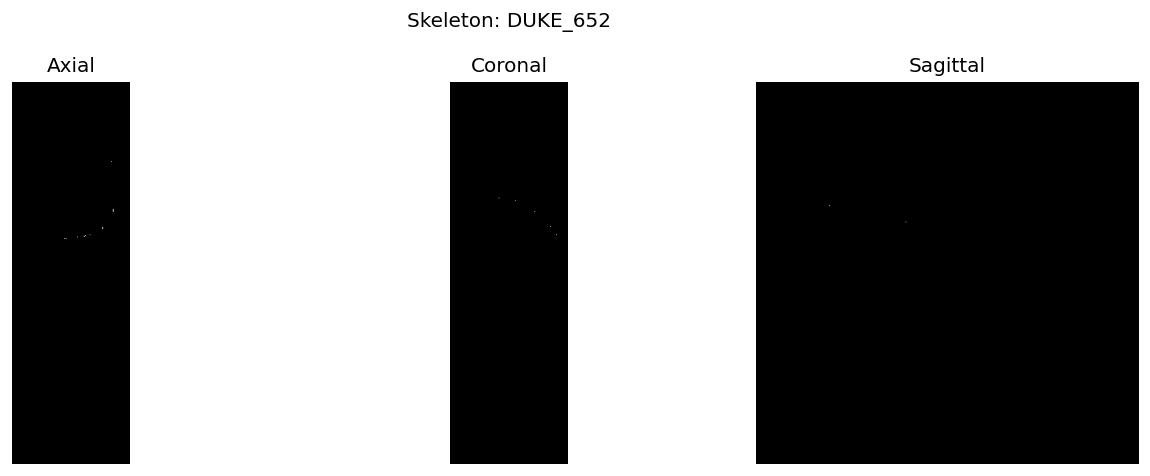

fn_ISPY1_1051.png


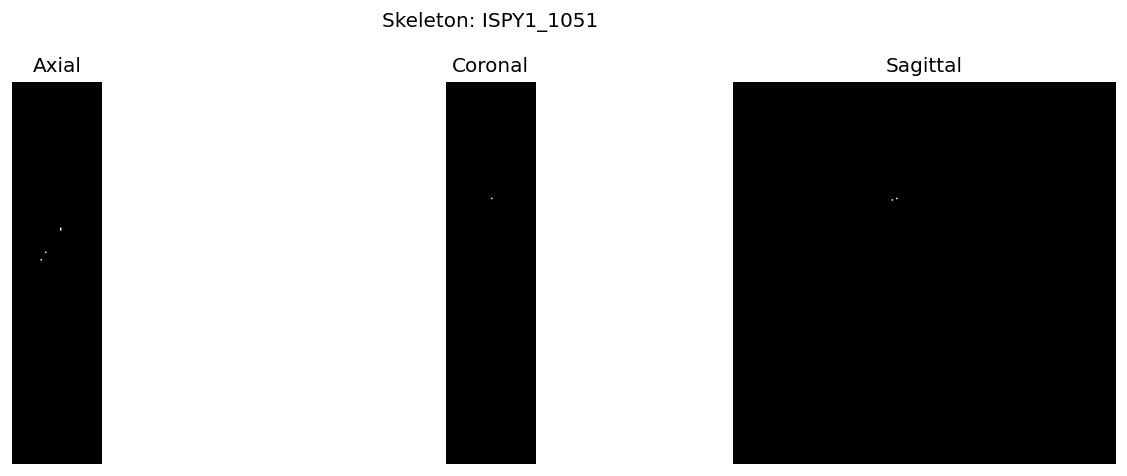

fn_ISPY1_1073.png


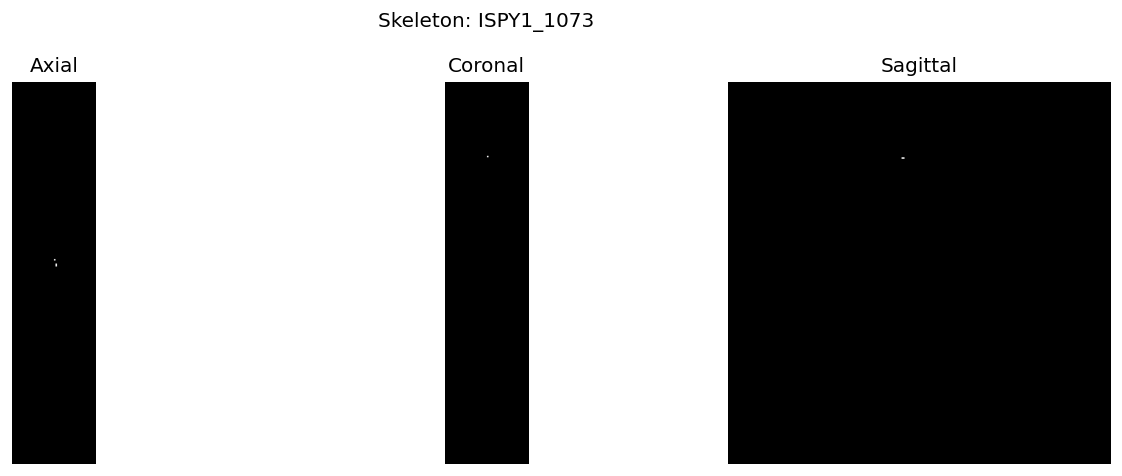

fn_ISPY1_1088.png


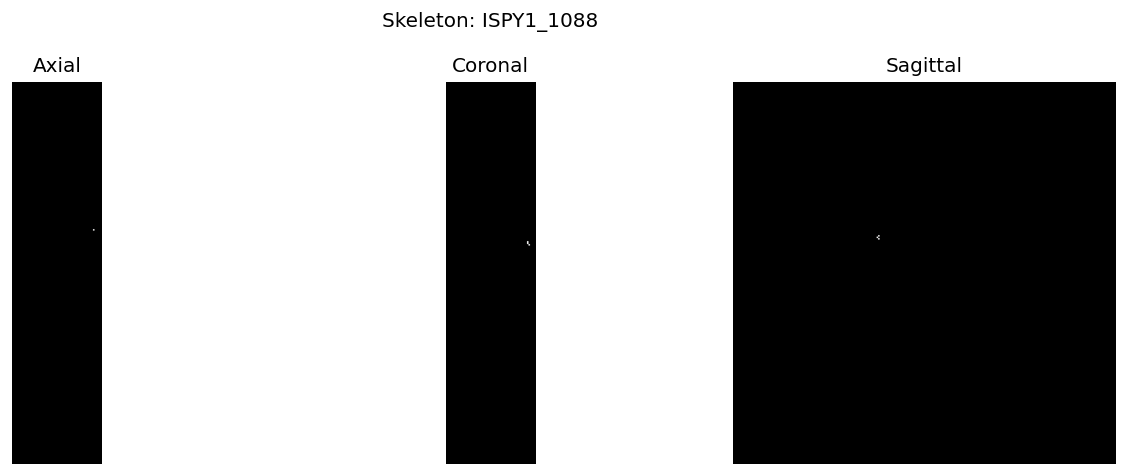

fn_ISPY1_1144.png


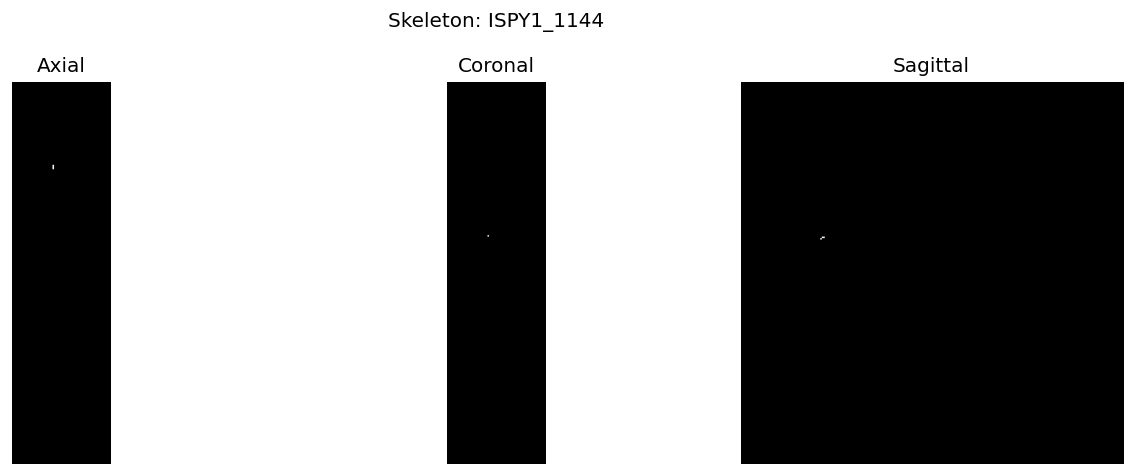

fn_ISPY2_188091.png


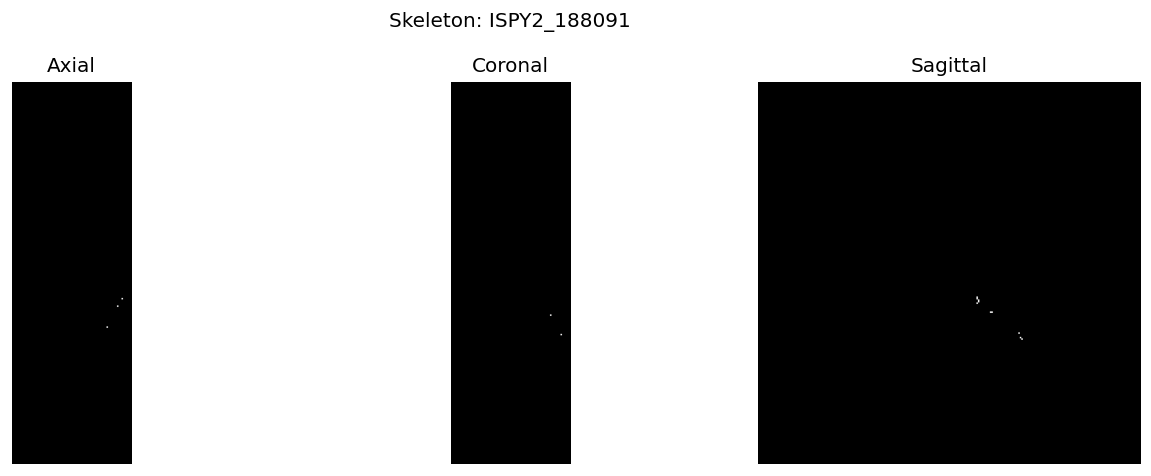

In [12]:
# Skeleton visualizations
viz_dir = REPORT_DIR / "viz"
if viz_dir.exists():
    for p in sorted(viz_dir.glob("*.png"))[:6]:
        print(p.name)
        display(Image(filename=str(p), width=400))
else:
    print("No analysis/viz/ directory")